# EJERCICIO 1 

En el repositorio, tenemos los archivos:

nacimientos_2020.csv nacimientos_2021.csv nacimientos_2022.csv

Cada archivo contiene información de nacimientos por estado.

Realiza lo siguiente:

Lee cada archivo usando pd.read_csv().
Agrega a cada base una columna llamada "Año", (Ej. nac_2020["Año"] = 2020).
Une las tres bases en un solo DataFrame llamado df_nacimientos (Utiliza pd.concat()).
Revisa las primeras filas con .head().
Revisa cuántas filas y columnas tiene la base final.
Calcula el total de nacimientos por año.
Identifica qué año tuvo más nacimientos y cuál tuvo menos.
Después responde:

¿Cuántos nacimientos hubo en total en 2020, 2021 y 2022?
¿En qué año se registró el mayor número de nacimientos?
¿En qué año se registró el menor número de nacimientos?
¿La cantidad de nacimientos parece aumentar o disminuir con el tiempo?

In [65]:
# Antes de comenzar importamos paqueterias 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [66]:
# ANEXAMOS LA RUTA DE LOS ARCHIVOS
naci20='https://raw.githubusercontent.com/jamc88/min-curso/refs/heads/main/Datos/nacimientos_2021.csv'
naci21='https://raw.githubusercontent.com/jamc88/min-curso/refs/heads/main/Datos/nacimientos_2021.csv'
naci22='https://raw.githubusercontent.com/jamc88/min-curso/refs/heads/main/Datos/nacimientos_2022.csv'

In [67]:
# LEEMOS LOS DATAFRAME
naci2020=pd.read_csv(naci20)
naci2021=pd.read_csv(naci21)
naci2022=pd.read_csv(naci22)


In [68]:
#Agregamos una nueva columna
naci2020['Año']=2020
naci2021['Año']=2021
naci2022['Año']=2022

In [69]:
# UNIMOS TOAS LAS BASES DE DATOS EN UN SOLO DATAFRAME
df_nacimientos=pd.concat([naci2020, naci2021, naci2022], ignore_index=True)

In [70]:
df_nacimientos.head()

,Estado,Abreviatura,Regiones,Mujeres,Hombres,No_esp,Total,Año
0,Aguascalientes,AG,Noreste,11266,11801,0,23067,2020
1,Baja California,BC,Noroeste,29364,29651,0,59015,2020
2,Baja California Sur,BS,Noroeste,5084,5158,0,10242,2020
3,Campeche,CM,Sureste,7049,7246,0,14295,2020
4,Coahuila de Zaragoza,CO,Noreste,23326,23802,0,47128,2020


In [12]:
# Revisa cuántas filas y columnas tiene la base final.
df_nacimientos.shape

(96, 8)

In [13]:
#Calcula el total de nacimientos por año.
total_año=df_nacimientos.groupby('Año')['Total'].sum()
total_año 

Año
2020    1903393
2021    1903393
2022    1880718
Name: Total, dtype: int64

In [14]:
menos=total_año.idxmin()
mas=total_año.idxmax()
print (f'El año con menos nacimientos es:{menos}')
print(f'El año con más nacimientos es:{mas}')

El año con menos nacimientos es:2022
El año con más nacimientos es:2020


In [15]:
#¿Cuántos nacimientos hubo en total en 2020, 2021 y 2022?
df_nacimientos['Total'].sum()

5687504

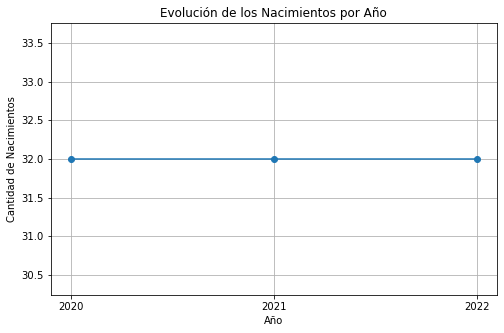

In [16]:
# Contar los nacimientos por año y graficar en una sola línea
df_nacimientos.groupby('Año').size().plot(kind='line', marker='o', grid=True, figsize=(8, 5))

plt.title('Evolución de los Nacimientos por Año')
plt.ylabel('Cantidad de Nacimientos')
plt.xlabel('Año')
plt.xticks([2020, 2021, 2022]) # Para que no salgan decimales en los años

plt.show()

In [ ]:
#notamos que es muy similar la cantidad de nacimientos por años

# EJERCICIO 2

In [ ]:
Usando la base nacimientos_2020.csv y el archivo poblacion.csv, realiza un análisis de la tasa de nacimientos por cada 100,000 habitantes del año 2020.

Realiza lo siguiente:

Lee la base de población.
Une la base de nacimientos con la base de población usando la columna del estado.
Crea una nueva columna llamada "Tasa_nacimientos" definida como:
Tasa_nacimientos = Nacimientos / Poblacion * 1_000
Calcula la tasa de nacimientos por estado y año.
Identifica los 5 estados con mayor tasa de nacimientos en 2020.
Identifica los 5 estados con menor tasa de nacimientos en 2020.
Grafica la tasa de nacimientos por estado para 2020.
Preguntas para responder:

¿Qué estado tuvo la mayor tasa de nacimientos en 2020?
¿Qué estado tuvo la menor tasa de nacimientos en 2020?
¿Los estados con más nacimientos absolutos son necesariamente los estados con mayor tasa?
¿Por qué es útil dividir entre la población?

In [17]:
naci20='https://raw.githubusercontent.com/jamc88/min-curso/refs/heads/main/Datos/nacimientos_2021.csv'
pob='https://raw.githubusercontent.com/jamc88/min-curso/refs/heads/main/Datos/poblacion.csv'

In [37]:
# LEEMOS LOS DATAFRAME
naci2020=pd.read_csv(naci20)
naci2020.head()

,Estado,Abreviatura,Regiones,Mujeres,Hombres,No_esp,Total
0,Aguascalientes,AG,Noreste,11266,11801,0,23067
1,Baja California,BC,Noroeste,29364,29651,0,59015
2,Baja California Sur,BS,Noroeste,5084,5158,0,10242
3,Campeche,CM,Sureste,7049,7246,0,14295
4,Coahuila de Zaragoza,CO,Noreste,23326,23802,0,47128


In [38]:
pobla=pd.read_csv(pob)
pobla.head()

,Estado,Regiones,H_1990,M_1990,H_2000,M_2000,H_2010,M_2010,H_2020,M_2020
0,Aguascalientes,Noreste,350218,369441,456533,487752,576638,608358,696683,728924
1,Baja California,Noroeste,832090,828765,1252581,1234786,1591610,1563460,1900589,1868431
2,Baja California Sur,Noroeste,161833,155931,216250,207791,325433,311593,405879,392568
3,Campeche,Sureste,268772,266413,344334,346355,407721,414720,456939,471424
4,Coahuila de Zaragoza,Noreste,979097,993243,1140195,1157875,1364197,1384194,1563669,1583102


In [39]:
#UNIMOS LOS DOS DATAFRAME
df=pd.merge(naci2020, pobla, on='Estado')
df.head()

,Estado,Abreviatura,Regiones_x,Mujeres,Hombres,No_esp,Total,Regiones_y,H_1990,M_1990,H_2000,M_2000,H_2010,M_2010,H_2020,M_2020
0,Aguascalientes,AG,Noreste,11266,11801,0,23067,Noreste,350218,369441,456533,487752,576638,608358,696683,728924
1,Baja California,BC,Noroeste,29364,29651,0,59015,Noroeste,832090,828765,1252581,1234786,1591610,1563460,1900589,1868431
2,Baja California Sur,BS,Noroeste,5084,5158,0,10242,Noroeste,161833,155931,216250,207791,325433,311593,405879,392568
3,Campeche,CM,Sureste,7049,7246,0,14295,Sureste,268772,266413,344334,346355,407721,414720,456939,471424
4,Coahuila de Zaragoza,CO,Noreste,23326,23802,0,47128,Noreste,979097,993243,1140195,1157875,1364197,1384194,1563669,1583102


In [52]:
#Crea una nueva columna llamada "Tasa_nacimientos" definida como:
df['Pobla2020']=df['H_2020']+df['M_2020']
df['Tasa_nacimientos_2020']=(df['Total'] / df['Pobla2020']) * 1000
df.head()

,Estado,Abreviatura,Regiones_x,Mujeres,Hombres,No_esp,Total,Regiones_y,H_1990,M_1990,H_2000,M_2000,H_2010,M_2010,H_2020,M_2020,Poblacion,Tasa_nacimientos,Pobla2020,Tasa_nacimientos_2020
0,Aguascalientes,AG,Noreste,11266,11801,0,23067,Noreste,350218,369441,456533,487752,576638,608358,696683,728924,1425607,16.180476,1425607,16.180476
1,Baja California,BC,Noroeste,29364,29651,0,59015,Noroeste,832090,828765,1252581,1234786,1591610,1563460,1900589,1868431,3769020,15.657916,3769020,15.657916
2,Baja California Sur,BS,Noroeste,5084,5158,0,10242,Noroeste,161833,155931,216250,207791,325433,311593,405879,392568,798447,12.827401,798447,12.827401
3,Campeche,CM,Sureste,7049,7246,0,14295,Sureste,268772,266413,344334,346355,407721,414720,456939,471424,928363,15.398072,928363,15.398072
4,Coahuila de Zaragoza,CO,Noreste,23326,23802,0,47128,Noreste,979097,993243,1140195,1157875,1364197,1384194,1563669,1583102,3146771,14.976622,3146771,14.976622


In [53]:
df[['Estado','Tasa_nacimientos_2020']]

,Estado,Tasa_nacimientos_2020
0,Aguascalientes,16.180476
1,Baja California,15.657916
2,Baja California Sur,12.827401
3,Campeche,15.398072
4,Coahuila de Zaragoza,14.976622
5,Colima,13.060046
6,Chiapas,26.389347
7,Chihuahua,14.690787
8,CDMX,10.243168
9,Durango,16.947590


In [54]:
#5 ESTADOS CON MAYOR TASA DE NACIMIENTOS EN 2020
df[['Estado', 'Tasa_nacimientos_2020']].sort_values(
    by='Tasa_nacimientos_2020',
    ascending=False
).head(5)

,Estado,Tasa_nacimientos_2020
6,Chiapas,26.389347
11,Guerrero,18.523817
26,Tabasco,17.950985
31,Zacatecas,17.533650
20,Puebla,17.438577


In [56]:
#5 estados con menor tasa de nacimientos en 2020.
df[['Estado', 'Tasa_nacimientos_2020']].sort_values(
    by='Tasa_nacimientos_2020'
).head(5)

,Estado,Tasa_nacimientos_2020
8,CDMX,10.243168
30,Yucatan,12.091871
12,Hidalgo,12.790475
2,Baja California Sur,12.827401
14,Mexico,12.911582


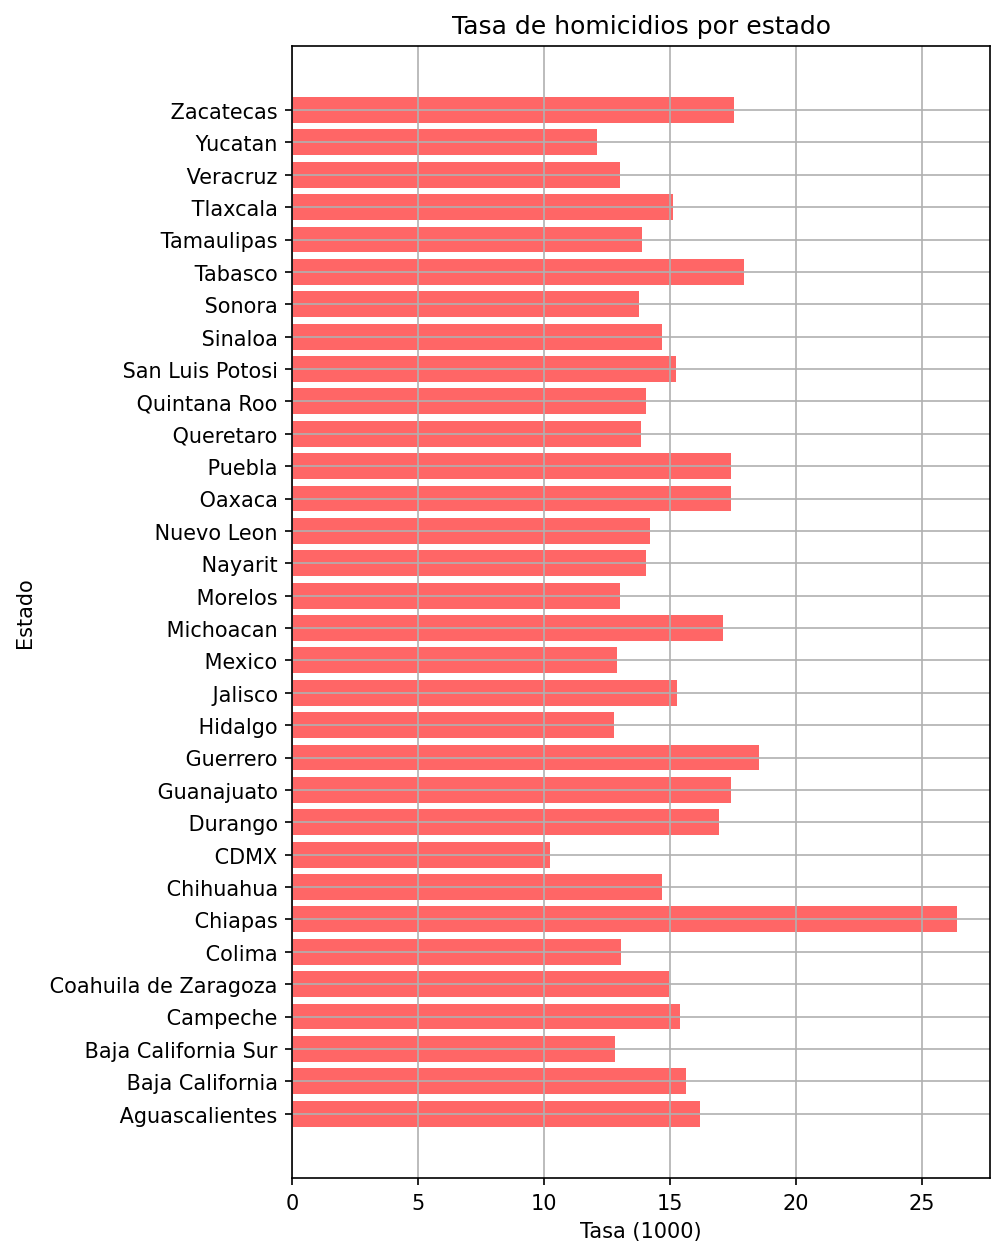

In [64]:
#Grafica la tasa de nacimientos por estado para 2020
plt.figure(figsize=(6, 10), dpi=150)
plt.barh(df['Estado'], df['Tasa_nacimientos_2020'], color = 'red', alpha=0.6)
plt.title('Tasa de homicidios por estado')
plt.ylabel('Estado')
plt.xlabel('Tasa (1000)')
plt.grid()
plt.show()

In [ ]:
¿Qué estado tuvo la mayor tasa de nacimientos en 2020
CHIAPAS
¿Qué estado tuvo la menor tasa de nacimientos en 2020
CDMX
¿Los estados con más nacimientos absolutos son necesariamente los estados con mayor tasa?
No, porque  tasa de nacimientos condera el numero de nacimientos asi como el 
tamaño de la población. por asi decirlo, un estado puede tener muchos nacimietos en numeros absolutos 
pero una tasa relativamente baja,etc.
¿Por qué es útil dividir entre la población? Porque permite comparar de manera mas clara el numero total de nacimientos y observar
los estados que tienen mas población de nacimientos. 